In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime as dt
import missingno as mso
import numpy as np
from dash import Dash, html, dcc, dash_table
import dash_bootstrap_components as dbc
import plotly.express as px


In [ ]:
df= pd.read_csv(r"D:\new\OneDrive\Desktop\New folder (2)\weatherAUS.csv")

In [7]:
df['Date']=pd.to_datetime(df['Date'])
print(df['Date'].dtype)

df['year']=df['Date'].dt.year
df['month']=df['Date'].dt.month
df['day']=df['Date'].dt.day
df['dat_of_week']=df['Date'].dt.day_of_week
df

datetime64[us]


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,year,month,day,dat_of_week
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,8.0,NaN,16.9,21.8,No,No,2008,12,1,0
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,NaN,NaN,17.2,24.3,No,No,2008,12,2,1
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,NaN,2.0,21.0,23.2,No,No,2008,12,3,2
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,NaN,NaN,18.1,26.5,No,No,2008,12,4,3
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,7.0,8.0,17.8,29.7,No,No,2008,12,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,...,NaN,NaN,10.1,22.4,No,No,2017,6,21,2
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,...,NaN,NaN,10.9,24.5,No,No,2017,6,22,3
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,...,NaN,NaN,12.5,26.1,No,No,2017,6,23,4
145458,2017-06-24,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,...,3.0,2.0,15.1,26.0,No,No,2017,6,24,5


In [8]:
df.drop(['Date'],axis=1,inplace=True)

In [9]:
df2 = df[df["month"] == 7].copy()

df2.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,year,month,day,dat_of_week
212,Albury,8.3,13.3,8.4,NaN,NaN,NW,52.0,N,NW,...,8.0,5.0,9.5,13.1,Yes,Yes,2009,7,1,2
213,Albury,8.8,11.6,5.0,NaN,NaN,WNW,54.0,NW,WNW,...,8.0,4.0,8.8,11.4,Yes,Yes,2009,7,2,3
214,Albury,7.6,12.0,7.8,NaN,NaN,W,61.0,W,WSW,...,8.0,1.0,7.8,11.7,Yes,No,2009,7,3,4
215,Albury,5.7,13.2,0.0,NaN,NaN,WNW,39.0,WNW,WNW,...,8.0,8.0,7.9,12.6,No,No,2009,7,4,5
216,Albury,3.4,12.4,0.0,NaN,NaN,W,31.0,W,W,...,NaN,NaN,7.0,12.0,No,No,2009,7,5,6


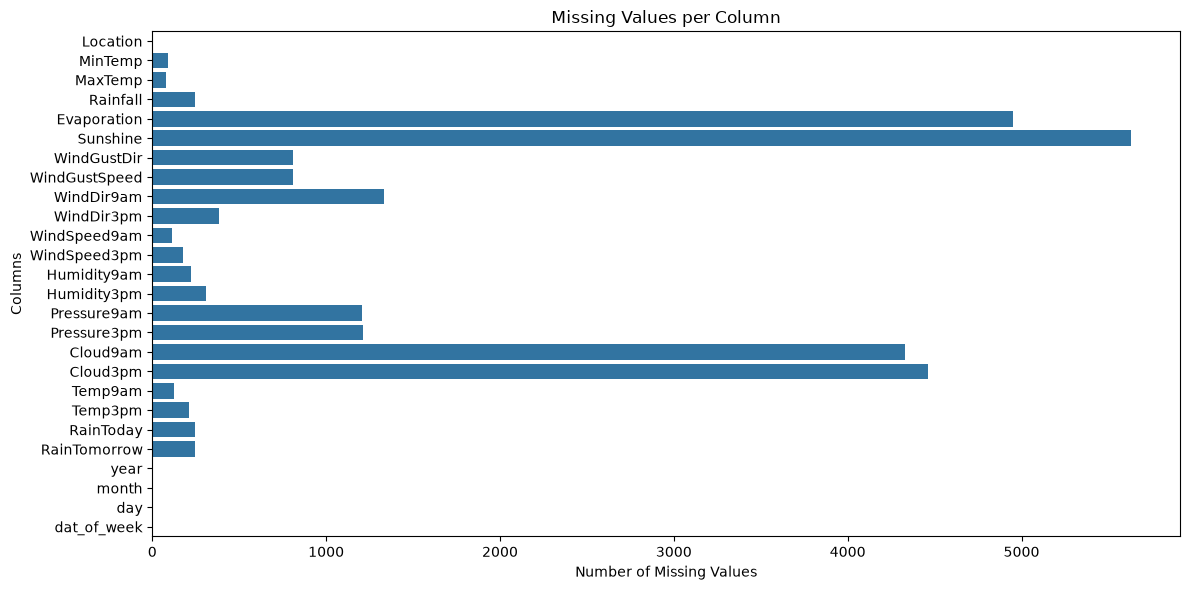

In [10]:
null_counts = df2.isnull().sum()
plt.figure(figsize=(12, 6))
sns.barplot(x=null_counts.values,y=null_counts.index)
plt.title("Missing Values per Column")
plt.xlabel("Number of Missing Values")
plt.ylabel("Columns")
plt.tight_layout()
plt.show()

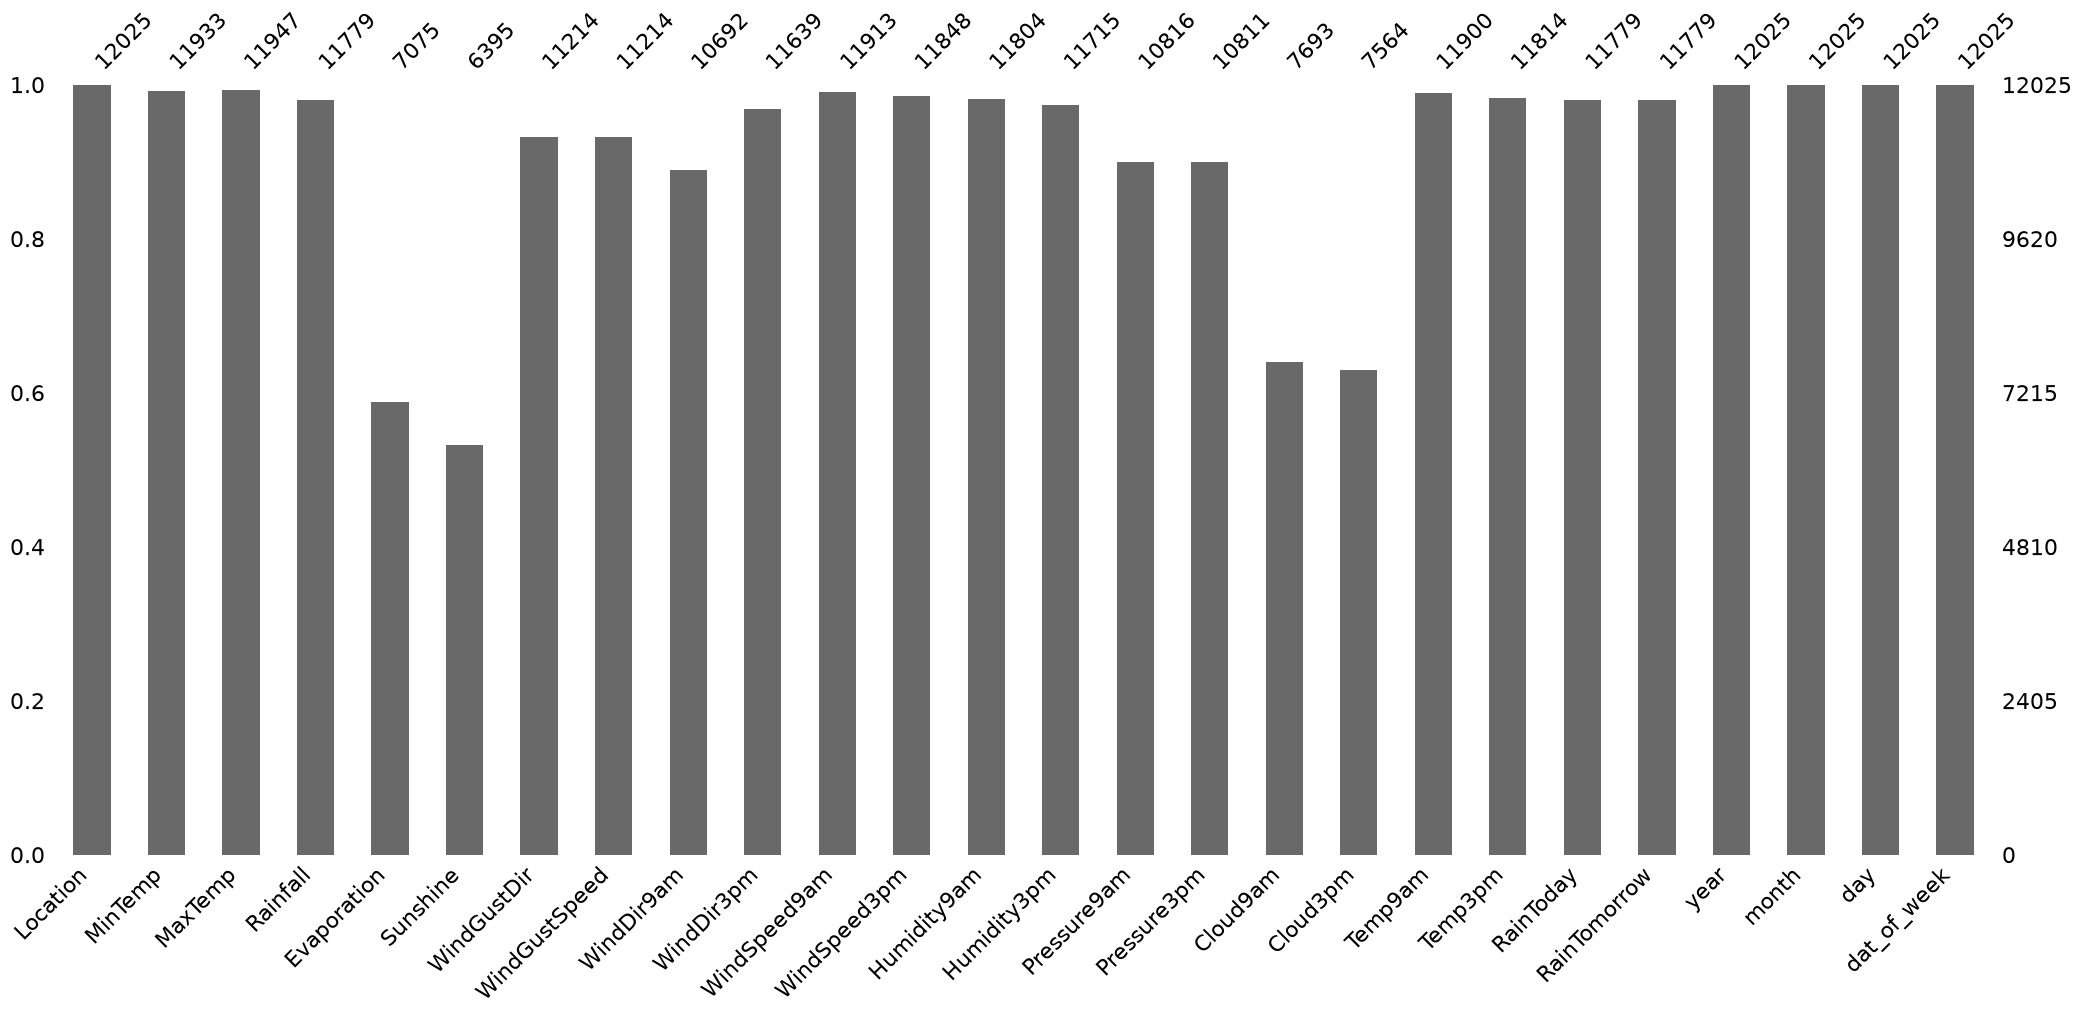

In [11]:
mso.bar(df2)
plt.show()

In [12]:
numerical_cols = df2.select_dtypes(include=[np.number]).columns.tolist()

In [13]:
numerical_cols=['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm']

In [14]:
numerical_cols

['MinTemp',
 'MaxTemp',
 'Rainfall',
 'WindGustSpeed',
 'WindSpeed9am',
 'WindSpeed3pm',
 'Humidity9am',
 'Humidity3pm',
 'Pressure9am',
 'Pressure3pm',
 'Temp9am',
 'Temp3pm']

In [15]:
for col in numerical_cols:
    df2[col] = (
        df2.groupby("Location")[col]
        .transform(lambda x: x.fillna(x.median()))
    )
for col in numerical_cols:
    df2[col] = df2[col].fillna(df2[col].median())    

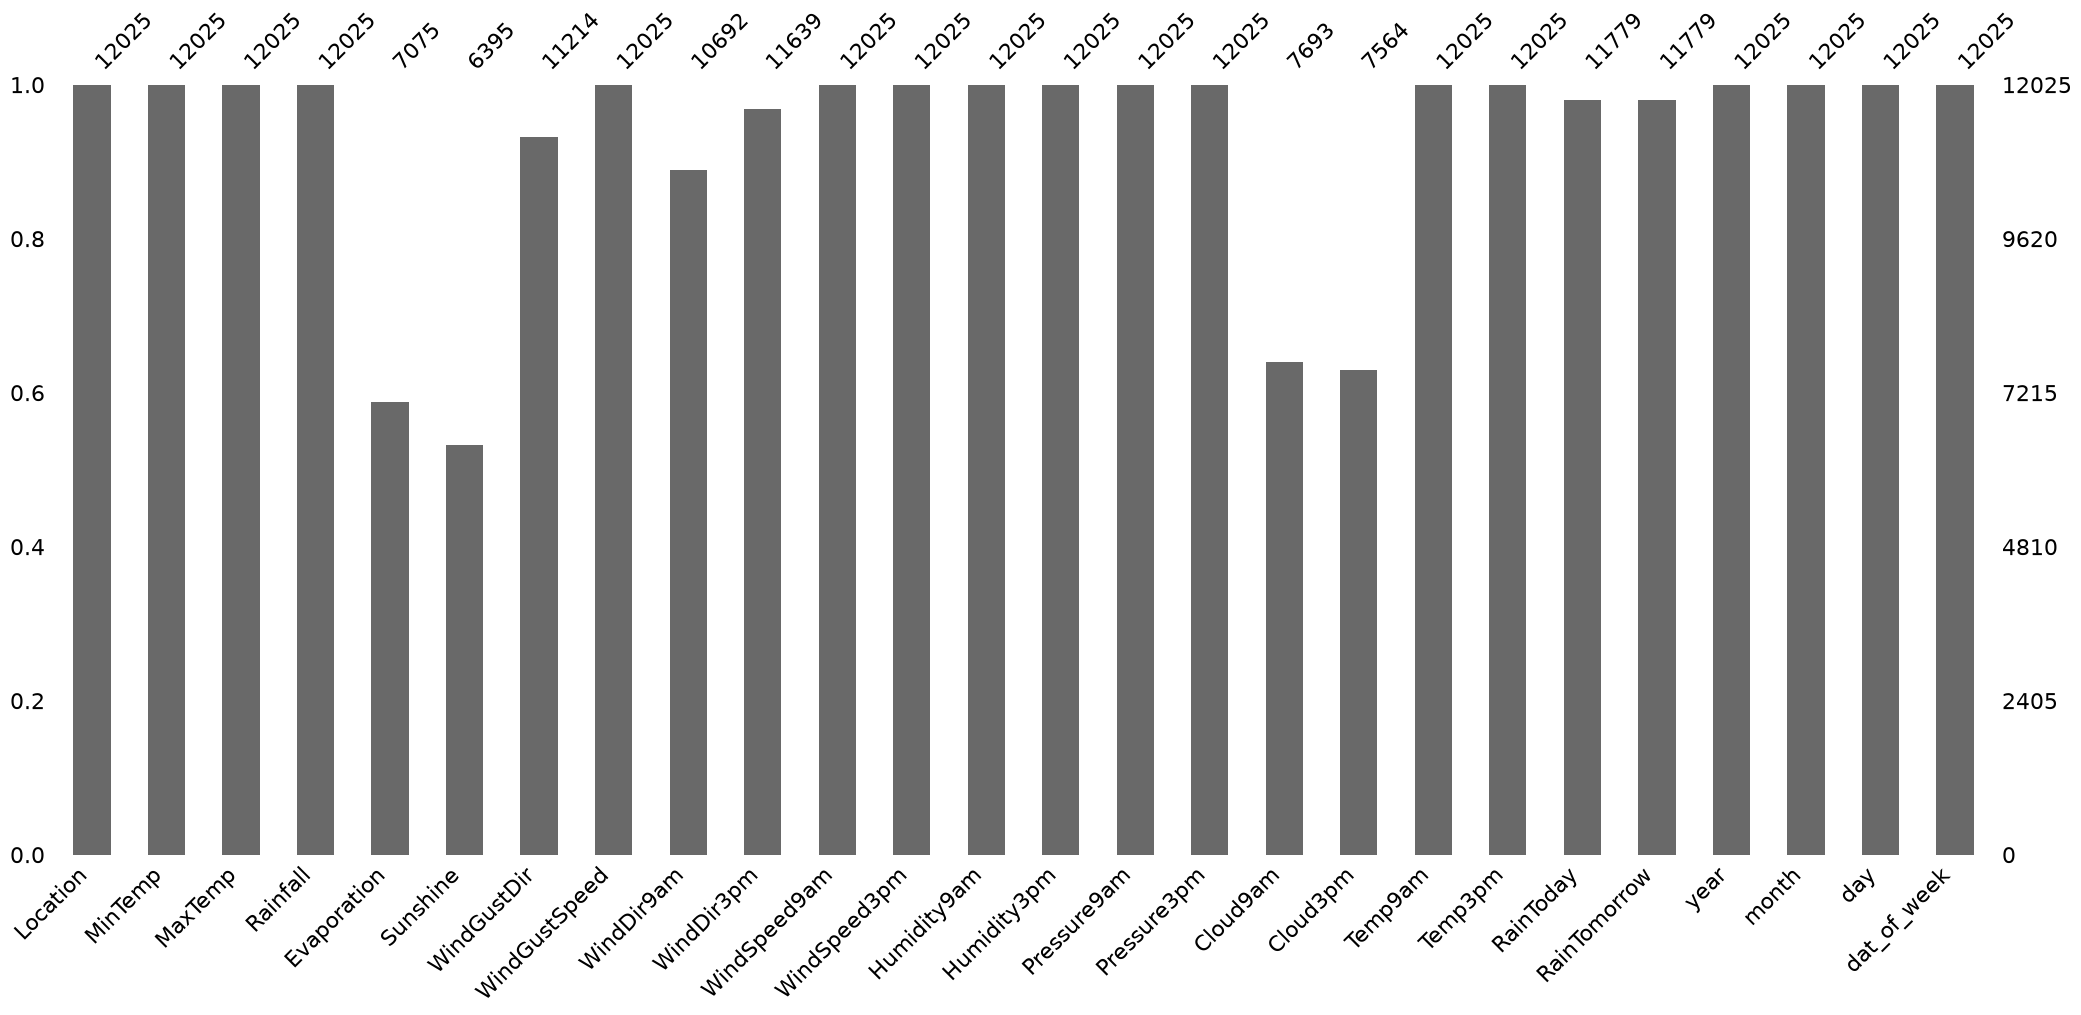

In [16]:
mso.bar(df2)
plt.show()

In [17]:
df2.columns

Index(['Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow', 'year', 'month', 'day',
       'dat_of_week'],
      dtype='str')

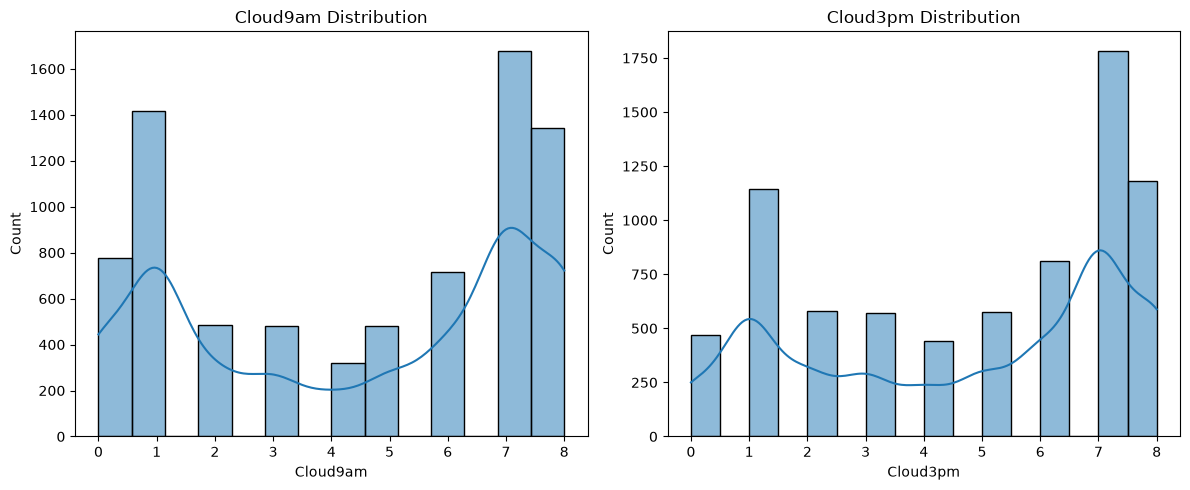

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df2['Cloud9am'], kde=True, ax=axes[0])
axes[0].set_title('Cloud9am Distribution')

sns.histplot(df2['Cloud3pm'], kde=True, ax=axes[1])
axes[1].set_title('Cloud3pm Distribution')

plt.tight_layout()
plt.show()

In [19]:
wind_columns = [
    "WindGustDir",
    "WindDir9am",
    "WindDir3pm",
    "RainToday",
    "RainTomorrow"
]

for col in wind_columns:

    group_mode = (
        df2.groupby(["Location"])[col]
        .transform(
            lambda x:
            x.mode().iloc[0]
            if not x.mode().empty
            else np.nan
        )
    )

    df2[col] = df2[col].fillna(group_mode)

    df2[col] = df2[col].fillna(
        df2[col].mode()[0]
    )


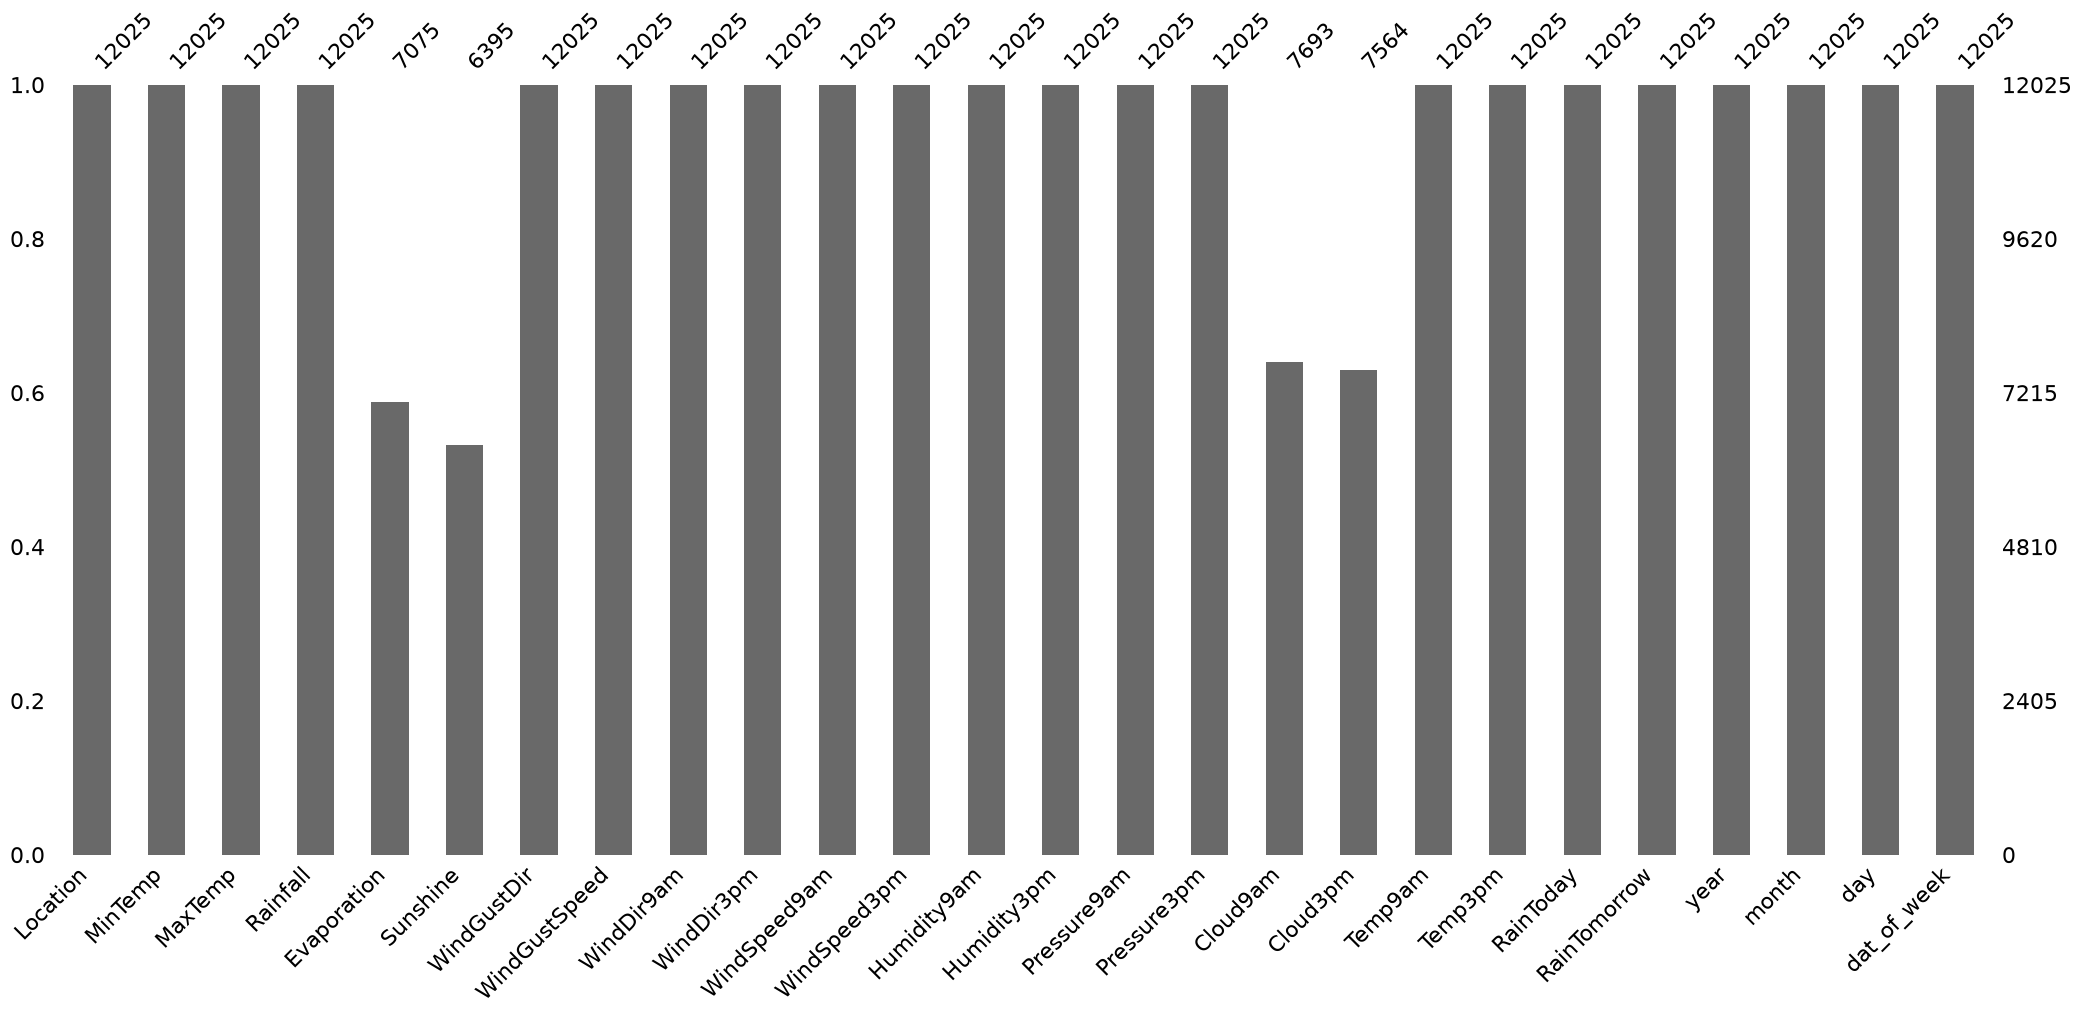

In [20]:
mso.bar(df2)
plt.show()

In [21]:
cols_for_cloud = [
    'Cloud9am',
    'Cloud3pm',
    'Sunshine',
    'Rainfall',
    'Humidity9am',
    'Humidity3pm',
    'Pressure9am',
    'Pressure3pm',
    'Temp9am',
    'Temp3pm',
    'MinTemp',
    'MaxTemp',
    'WindGustSpeed',
    'WindSpeed9am',
    'WindSpeed3pm'
]
corr_cloud = df2[cols_for_cloud].corr(numeric_only=True)

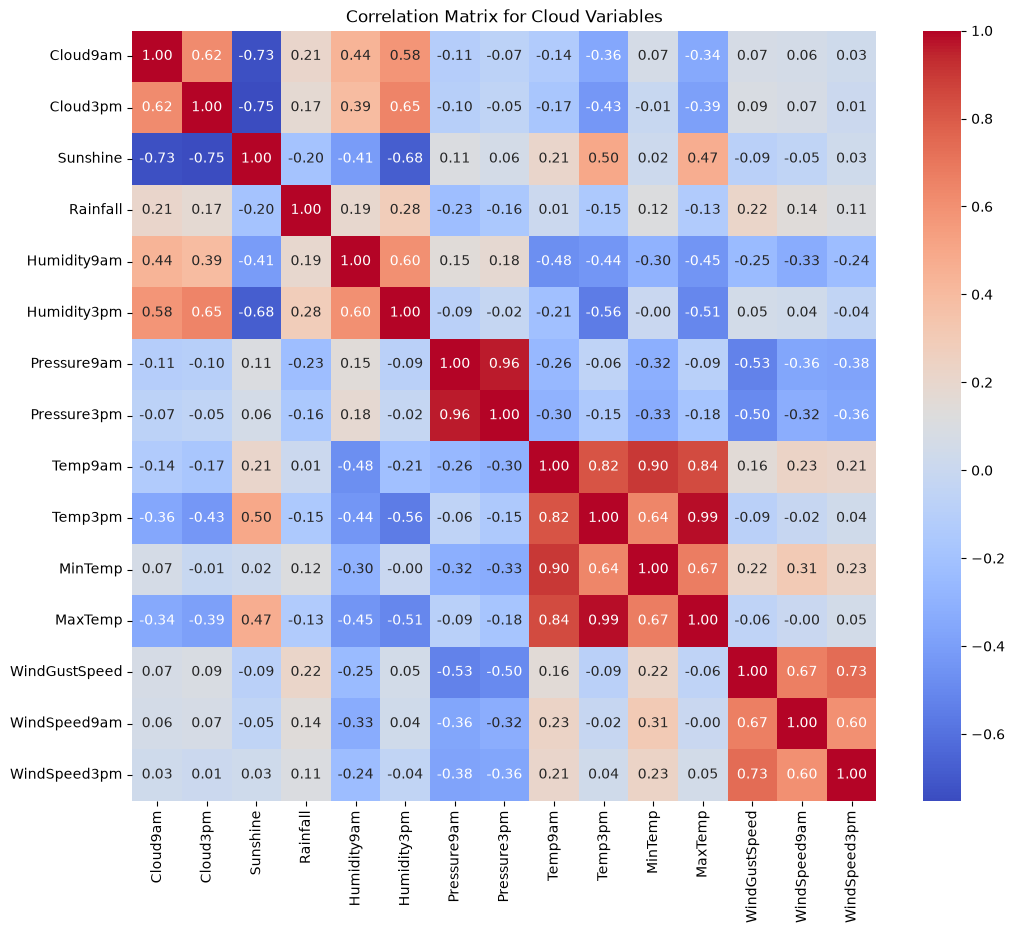

In [22]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_cloud,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Matrix for Cloud Variables')
plt.show()


In [23]:
cloud_Realation = [
    'Humidity3pm',
    'Humidity9am',
    'Rainfall',
    'Temp3pm',
    'Temp9am'
]

In [24]:
df2['Humidity9am_group'] = pd.qcut(
    df2['Humidity9am'],
    q=5,
    duplicates='drop'
)

df2['Humidity3pm_group'] = pd.qcut(
    df2['Humidity3pm'],
    q=5,
    duplicates='drop'
)

cloud9am_median = (
    df2
    .groupby(
        ['Location', 'Humidity9am_group', 'Humidity3pm_group'],
        observed=True
    )['Cloud9am']
    .transform('median')
)

df2['Cloud9am'] = df2['Cloud9am'].fillna(
    cloud9am_median
)
location_median = (
    df2.groupby('Location')['Cloud9am']
    .transform('median')
)

df2['Cloud9am'] = df2['Cloud9am'].fillna(
    location_median
)

df2['Cloud9am'] = df2['Cloud9am'].fillna(
    df2['Cloud9am'].median()
)
cloud3pm_median = (
    df2
    .groupby(
        ['Location', 'Humidity9am_group', 'Humidity3pm_group'],
        observed=True
    )['Cloud3pm']
    .transform('median')
)

df2['Cloud3pm'] = df2['Cloud3pm'].fillna(
    cloud3pm_median
)
location_median = (
    df2.groupby('Location')['Cloud3pm']
    .transform('median')
)

df2['Cloud3pm'] = df2['Cloud3pm'].fillna(
    location_median
)

df2['Cloud3pm'] = df2['Cloud3pm'].fillna(
    df2['Cloud3pm'].median()
)

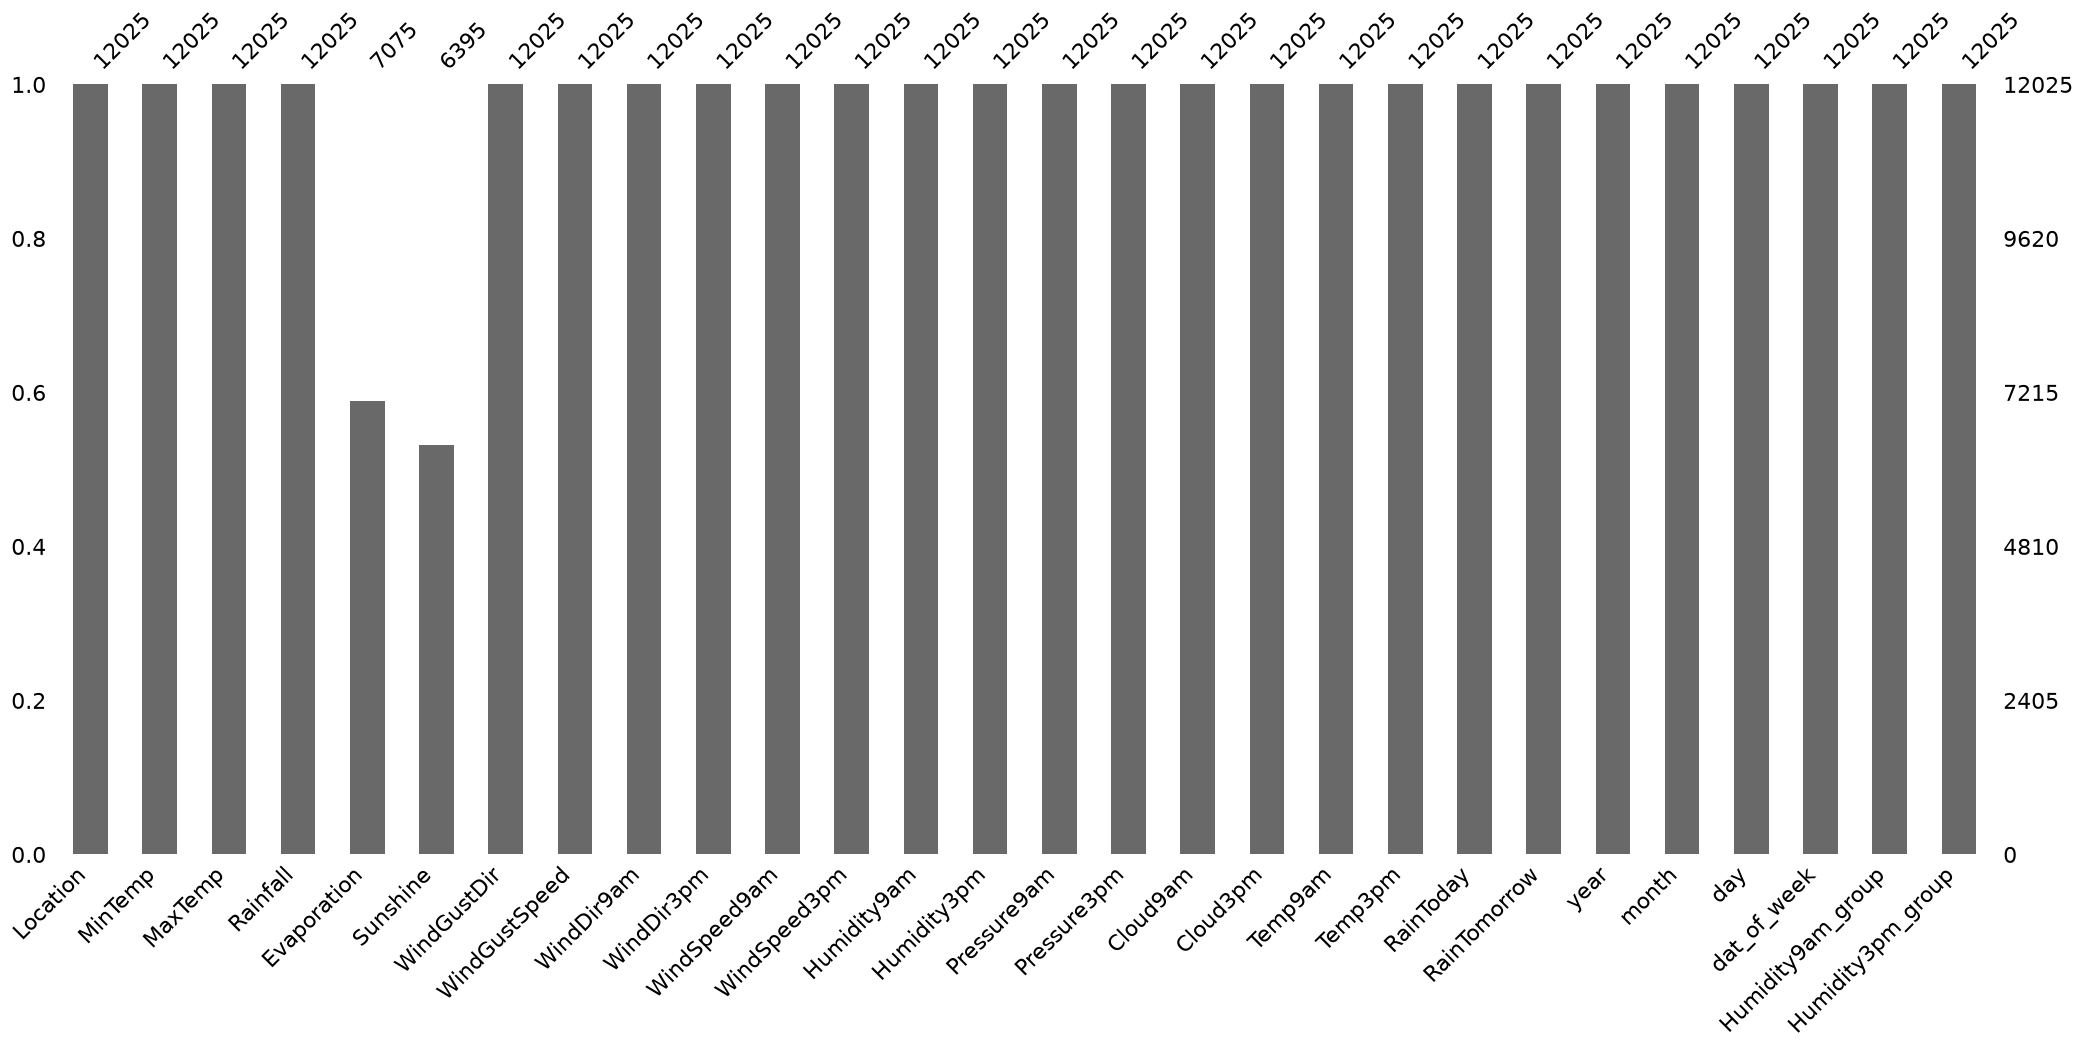

In [25]:
mso.bar(df2)
plt.show()

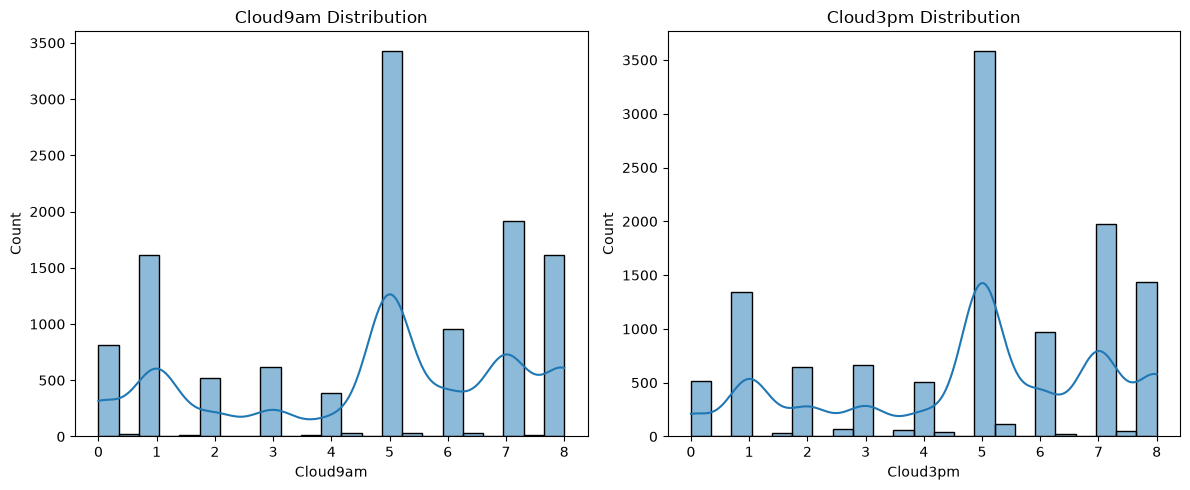

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df2['Cloud9am'], kde=True, ax=axes[0])
axes[0].set_title('Cloud9am Distribution')

sns.histplot(df2['Cloud3pm'], kde=True, ax=axes[1])
axes[1].set_title('Cloud3pm Distribution')

plt.tight_layout()
plt.show()

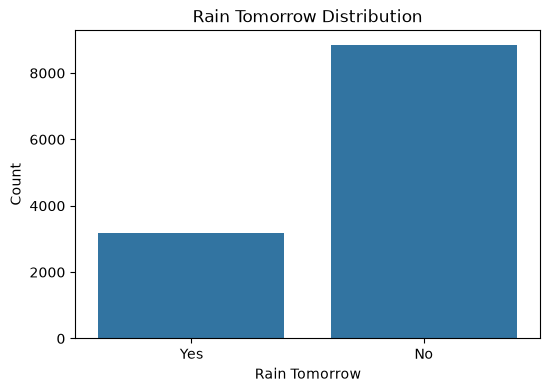

In [27]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df2,
    x='RainTomorrow'
)

plt.title('Rain Tomorrow Distribution')
plt.xlabel('Rain Tomorrow')
plt.ylabel('Count')

plt.show()

In [28]:
save_df2=df2.to_csv(r"D:\new\Downloads\archive (11)\weatherAUS_cleaned.csv", index=False)

In [29]:
df2.columns

Index(['Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow', 'year', 'month', 'day',
       'dat_of_week', 'Humidity9am_group', 'Humidity3pm_group'],
      dtype='str')

In [30]:
n_corr=['Evaporation','Sunshine' , 'Rainfall', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm','Cloud9am', 'Cloud3pm', 'MinTemp', 'MaxTemp']
corr_data = df2[n_corr].corr(numeric_only=True)

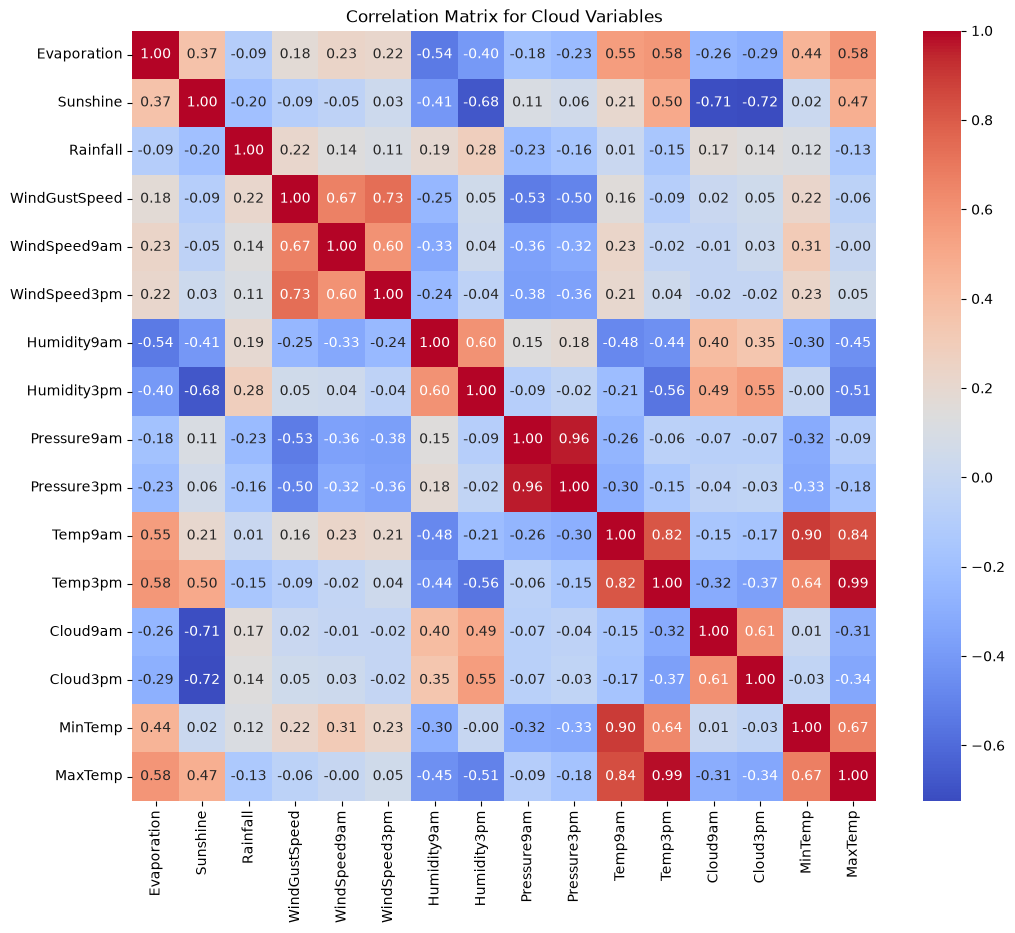

In [31]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_data,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Matrix for Cloud Variables')
plt.show()

In [32]:
df2['Humidity9am_group'] = pd.qcut(
    df2['Humidity9am'],
    q=5,
    duplicates='drop'
)

df2['Humidity3pm_group'] = pd.qcut(
    df2['Humidity3pm'],
    q=5,
    duplicates='drop'
)

df2['Cloud9am_group'] = pd.qcut(
    df2['Cloud9am'],
    q=5,
    duplicates='drop'
)

df2['Cloud3pm_group'] = pd.qcut(
    df2['Cloud3pm'],
    q=5,
    duplicates='drop'
)

In [33]:
sunshine_median = (
    df2
    .groupby(
        [
            'Location',
            'Humidity9am_group',
            'Humidity3pm_group',
            'Cloud9am_group',
            'Cloud3pm_group'
        ],
        observed=True
    )['Sunshine']
    .transform('median')
)

df2['Sunshine'] = df2['Sunshine'].fillna(
    sunshine_median
)

location_sunshine = (
    df2.groupby('Location')['Sunshine']
    .transform('median')
)

df2['Sunshine'] = df2['Sunshine'].fillna(
    location_sunshine
)

df2['Sunshine'] = df2['Sunshine'].fillna(
    df2['Sunshine'].median()
)

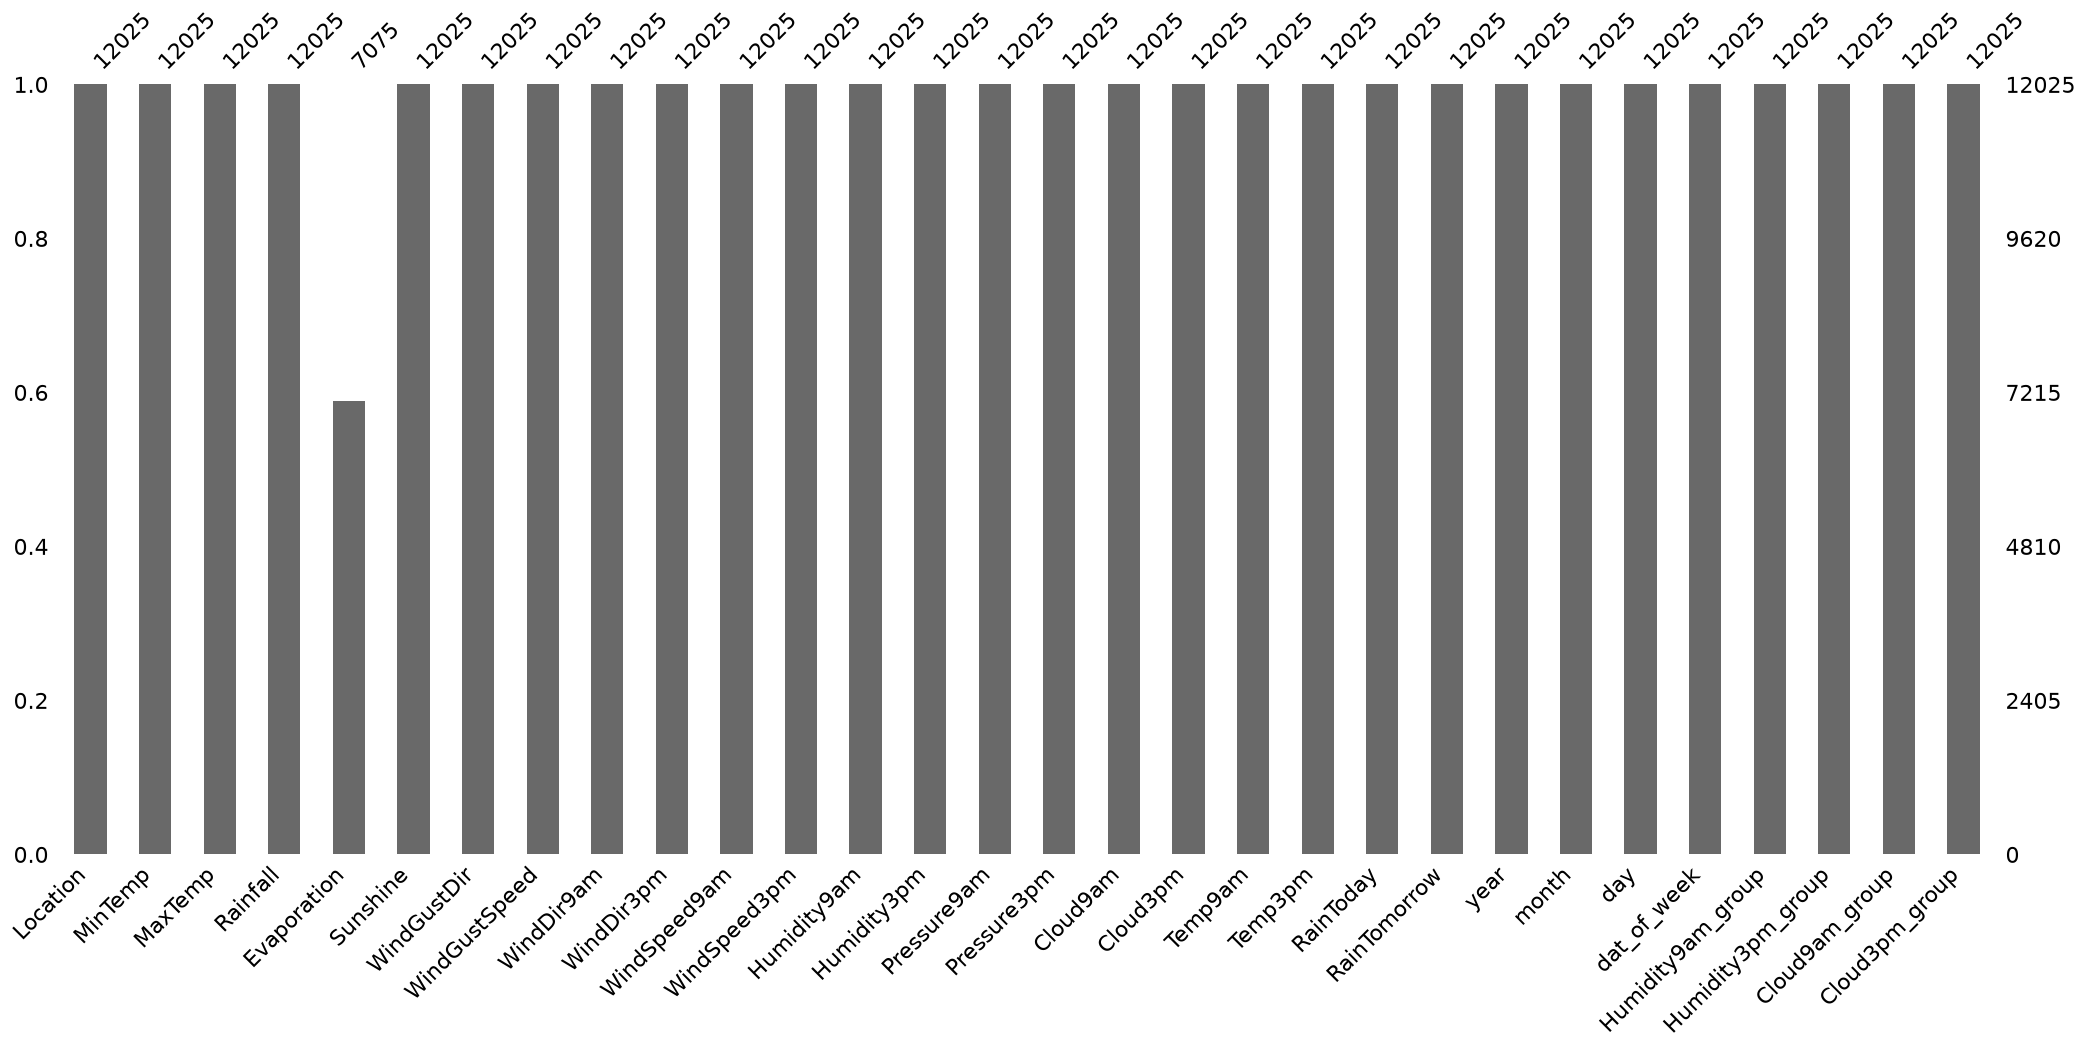

In [34]:
mso.bar(df2)
plt.show()

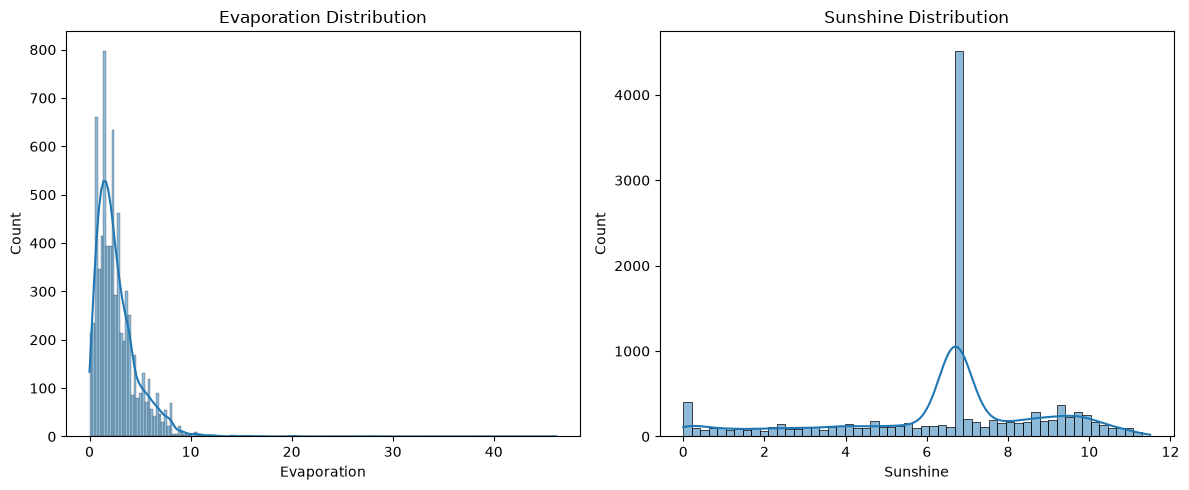

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df2['Evaporation'], kde=True, ax=axes[0])
axes[0].set_title('Evaporation Distribution')

sns.histplot(df2['Sunshine'], kde=True, ax=axes[1])
axes[1].set_title('Sunshine Distribution')

plt.tight_layout()
plt.show()

In [36]:
df2['MaxTemp_group'] = pd.qcut(
    df2['MaxTemp'],
    q=5,
    duplicates='drop'
)

df2['Temp3pm_group'] = pd.qcut(
    df2['Temp3pm'],
    q=5,
    duplicates='drop'
)

df2['Humidity3pm_group'] = pd.qcut(
    df2['Humidity3pm'],
    q=5,
    duplicates='drop'
)

df2['Sunshine_group'] = pd.qcut(
    df2['Sunshine'],
    q=5,
    duplicates='drop'
)

df2['WindSpeed3pm_group'] = pd.qcut(
    df2['WindSpeed3pm'],
    q=5,
    duplicates='drop'
)

df2['WindSpeed9am_group'] = pd.qcut(
    df2['WindSpeed9am'],
    q=5,
    duplicates='drop'
)


evaporation_median = (
    df2
    .groupby(
        [
            'Location',
            'MaxTemp_group',
            'Temp3pm_group',
            'Humidity3pm_group',
            'Sunshine_group',
            'WindSpeed3pm_group',
            'WindSpeed9am_group'
        ],
        observed=True
    )['Evaporation']
    .transform('median')
)

df2['Evaporation'] = df2['Evaporation'].fillna(
    evaporation_median
)


location_evaporation = (
    df2.groupby('Location')['Evaporation']
    .transform('median')
)

df2['Evaporation'] = df2['Evaporation'].fillna(
    location_evaporation
)


df2['Evaporation'] = df2['Evaporation'].fillna(
    df2['Evaporation'].median()
)

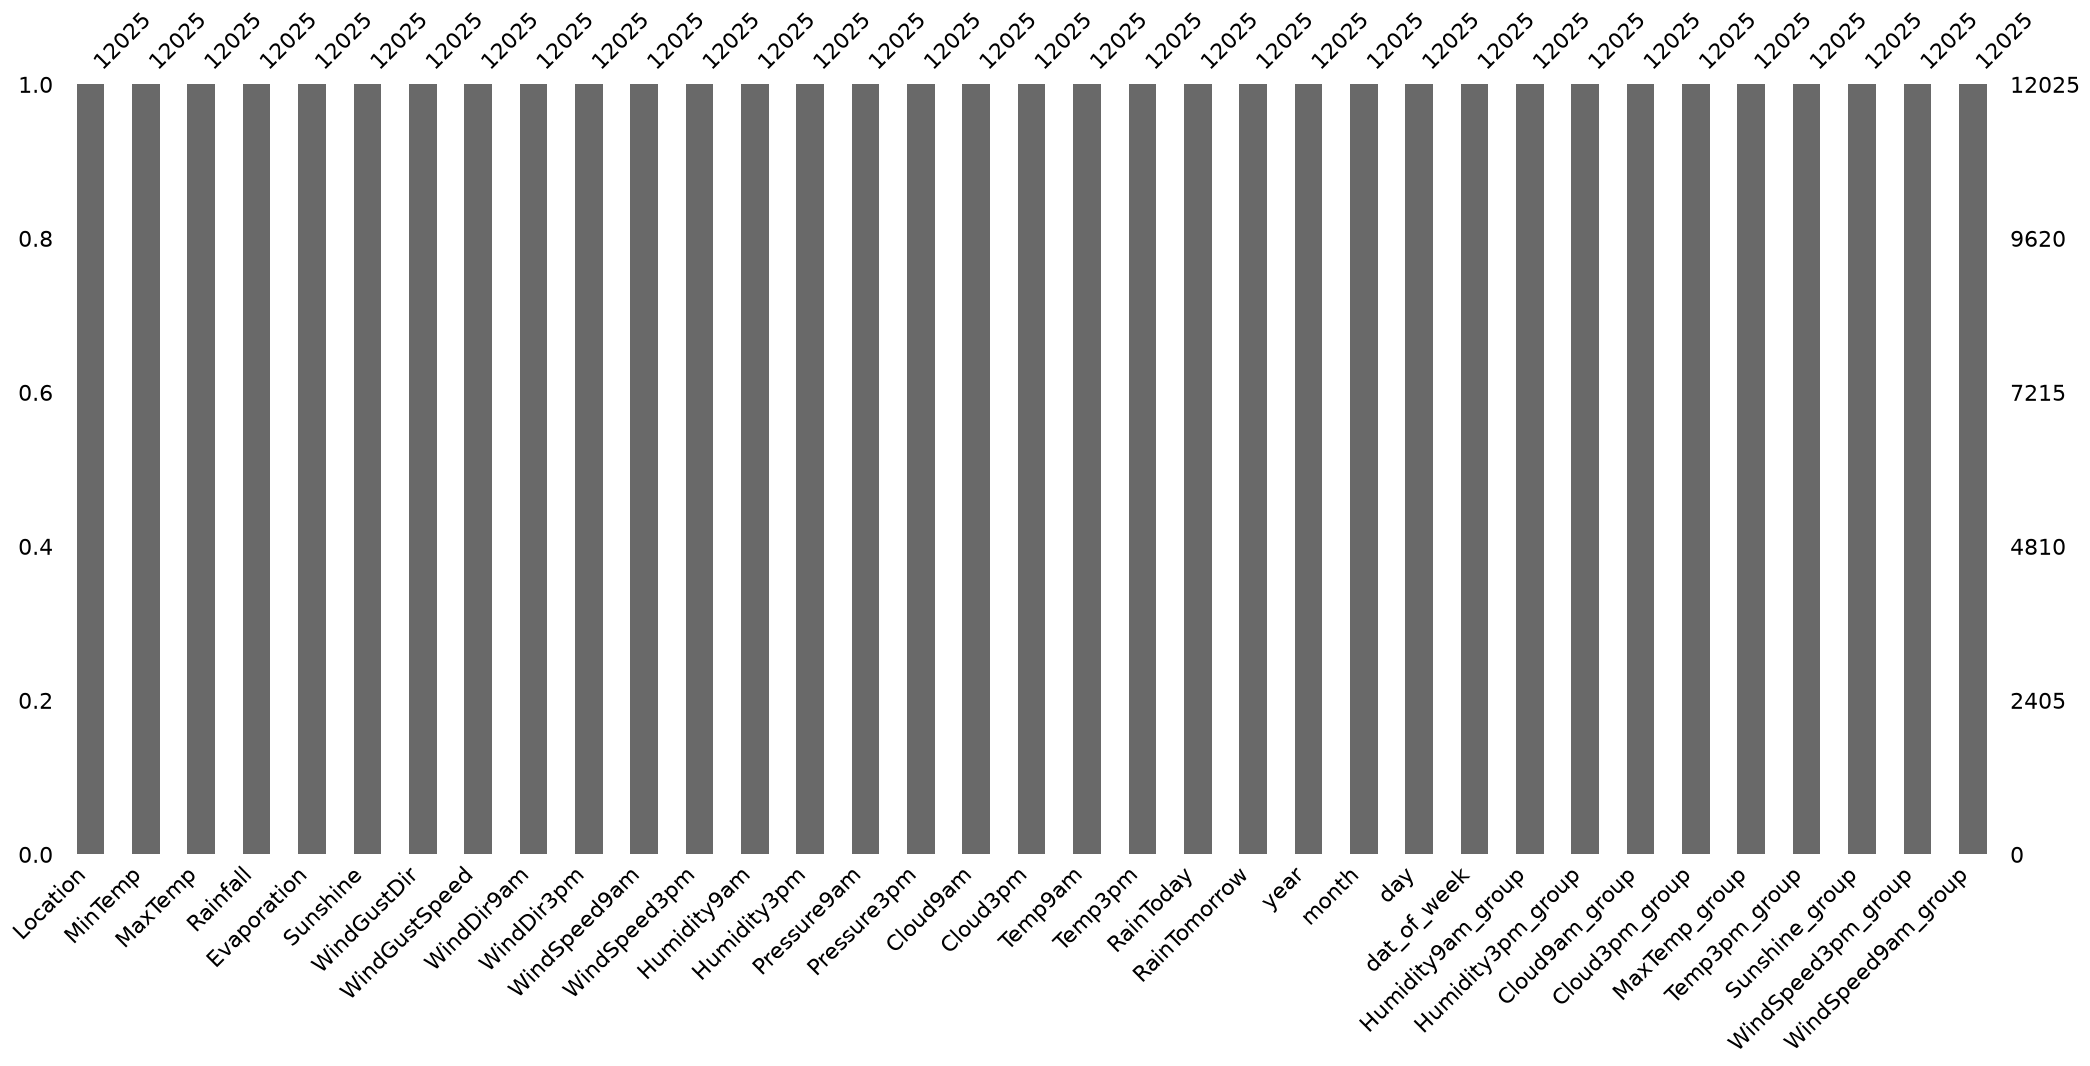

In [37]:
mso.bar(df2)
plt.show()

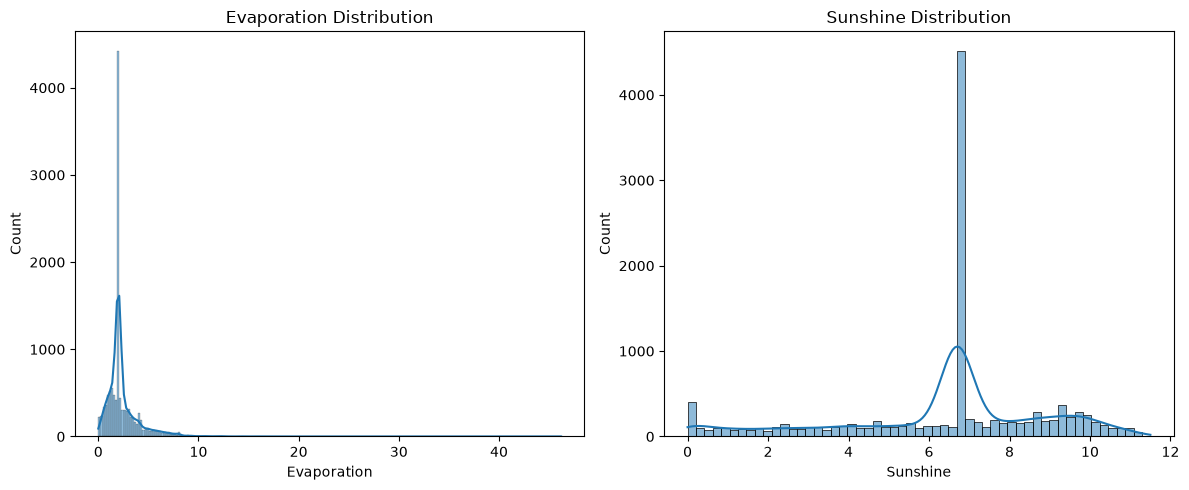

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df2['Evaporation'], kde=True, ax=axes[0])
axes[0].set_title('Evaporation Distribution')

sns.histplot(df2['Sunshine'], kde=True, ax=axes[1])
axes[1].set_title('Sunshine Distribution')

plt.tight_layout()
plt.show()

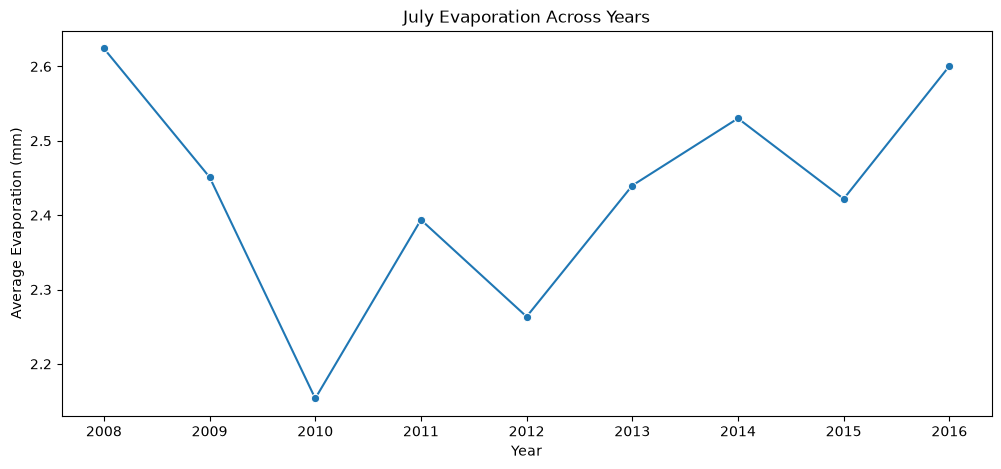

In [39]:
july_yearly = (

    df2.groupby("year")["Evaporation"] 

        .mean()

)

plt.figure(figsize=(12, 5))
sns.lineplot(

    x=july_yearly.index,

    y=july_yearly.values,

    marker="o"

)

plt.title("July Evaporation Across Years")
plt.xlabel("Year")
plt.ylabel("Average Evaporation (mm)")

plt.show()


In [40]:
df2.columns

Index(['Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow', 'year', 'month', 'day',
       'dat_of_week', 'Humidity9am_group', 'Humidity3pm_group',
       'Cloud9am_group', 'Cloud3pm_group', 'MaxTemp_group', 'Temp3pm_group',
       'Sunshine_group', 'WindSpeed3pm_group', 'WindSpeed9am_group'],
      dtype='str')

In [41]:
save_df2=df2.to_csv(r"D:\new\Downloads\archive (11)\weatherAUS_cleaned.csv", index=False)

In [ ]:
df2 = df2.copy()

for col in df2.columns:
    if isinstance(df2[col].dtype, pd.CategoricalDtype):
        df2[col] = df2[col].astype(str)



app = Dash(
    __name__,
    external_stylesheets=[dbc.themes.BOOTSTRAP]
)

app.layout = dbc.Container([

  
    html.H1(
        children='July Rain Data Analysis',
        className='text-center my-4'
    ),

    html.P(
        children='Rainfall Analysis for July',
        className='text-center text-muted mb-4'
    ),



    html.H3(
        'July Weather Data',
        className='mt-4 mb-3'
    ),

    dash_table.DataTable(
        data=df2.head(100).to_dict('records'),

        columns=[
            {
                'name': col,
                'id': col
            }
            for col in df2.columns
        ],

        page_size=15,

        style_table={
            'overflowX': 'auto'
        },

        style_cell={
            'textAlign': 'center',
            'padding': '10px',
            'minWidth': '120px',
            'maxWidth': '200px',
            'whiteSpace': 'normal'
        },

        style_header={
            'fontWeight': 'bold',
            'textAlign': 'center'
        }
    ),


    html.H3(
        'Rain Today Distribution',
        className='mt-5 mb-3'
    ),

    dcc.Graph(
        figure=px.histogram(
            df2,
            x='RainToday',
            title='Rain Today Distribution'
        )
    ),


    html.H3(
        'Rain Pattern by Year',
        className='mt-5 mb-3'
    ),

    dcc.Graph(
        figure=px.histogram(
            df2,
            x='year',
            color='RainToday',
            barmode='group',
            title='Rain Pattern in July by Year'
        )
    ),


    html.H3(
        'Sunshine vs Rain Today',
        className='mt-5 mb-3'
    ),

    dcc.Graph(
        figure=px.box(
            df2,
            x='RainToday',
            y='Sunshine',
            title='Sunshine vs Rain Today'
        )
    ),



    html.H3(
        'Evaporation vs Rain Today',
        className='mt-5 mb-3'
    ),

    dcc.Graph(
        figure=px.box(
            df2,
            x='RainToday',
            y='Evaporation',
            title='Evaporation vs Rain Today'
        )
    ),


    html.H3(
        'Cloud 3pm vs Rain Today',
        className='mt-5 mb-3'
    ),

    dcc.Graph(
        figure=px.box(
            df2,
            x='RainToday',
            y='Cloud3pm',
            title='Cloud 3pm vs Rain Today'
        )
    ),



    html.H3(
        'Wind Direction vs Rain Today',
        className='mt-5 mb-3'
    ),

    dcc.Graph(
        figure=px.histogram(
            df2,
            x='WindDir3pm',
            color='RainToday',
            barmode='group',
            title='Wind Direction vs Rain Today'
        )
    )

], fluid=True)



if __name__ == "__main__":
    app.run(
        debug=True,
        port=8020
    )

In [45]:
df_2008 = df[df['year'] == 2008]

df_2008

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,year,month,day,dat_of_week
0,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,...,8.0,NaN,16.9,21.8,No,No,2008,12,1,0
1,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,...,NaN,NaN,17.2,24.3,No,No,2008,12,2,1
2,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,...,NaN,2.0,21.0,23.2,No,No,2008,12,3,2
3,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,...,NaN,NaN,18.1,26.5,No,No,2008,12,4,3
4,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,...,7.0,8.0,17.8,29.7,No,No,2008,12,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139290,Darwin,25.9,34.4,3.0,4.8,7.7,NE,33.0,SSW,W,...,5.0,7.0,29.4,32.8,Yes,Yes,2008,12,27,5
139291,Darwin,23.6,32.6,12.4,5.6,4.0,WSW,37.0,WSW,W,...,4.0,7.0,30.6,31.1,Yes,No,2008,12,28,6
139292,Darwin,27.4,31.3,0.0,4.0,1.1,S,54.0,WSW,S,...,7.0,8.0,30.1,23.7,No,Yes,2008,12,29,0
139293,Darwin,23.4,29.3,22.2,3.8,0.1,WNW,50.0,WNW,WSW,...,7.0,7.0,26.7,29.3,Yes,Yes,2008,12,30,1


In [46]:
save_df_2008=df_2008.to_csv(r"D:\new\Downloads\archive (11)\weather_2008.csv", index=False)